# Notebook 00: VisDrone Dataset Exploration

This notebook explores the VisDrone2019-DET dataset before any training:
- Dataset structure and split sizes
- Annotation format and conversion
- Class distribution analysis
- Object size analysis (small-object challenge)
- Sample image visualisations
- Scene density analysis

In [1]:
import sys
from pathlib import Path

# Project root
ROOT = Path('..').resolve()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image
from tqdm import tqdm

sns.set_theme(style='whitegrid')
print('ROOT:', ROOT)

ROOT: /Users/toriav/Desktop/Erem/CMPE 401/Instructor Projects/Project 1/Object-Detection-Study-using-YOLOv11-or-YOLOv26-


## 1. Dataset Structure

In [2]:
DATA_ROOT = ROOT / 'data'

splits = {
    'train':          DATA_ROOT / 'VisDrone2019-DET-train',
    'val':            DATA_ROOT / 'VisDrone2019-DET-val',
    'test-dev':       DATA_ROOT / 'VisDrone2019-DET-test-dev',
    'test-challenge': DATA_ROOT / 'VisDrone2019-DET-test-challenge',
}

print(f"{'Split':<20} {'Images':>8} {'Annotations':>12}")
print('-' * 42)
for name, path in splits.items():
    n_img = len(list((path / 'images').glob('*.jpg'))) if (path / 'images').exists() else 0
    n_ann = len(list((path / 'annotations').glob('*.txt'))) if (path / 'annotations').exists() else 0
    print(f"{name:<20} {n_img:>8} {n_ann:>12}")

Split                  Images  Annotations
------------------------------------------
train                    6471         6471
val                       548          548
test-dev                 1610         1610
test-challenge           1580            0


## 2. Annotation Format

VisDrone annotations are CSV files, one file per image:
```
<bbox_left>,<bbox_top>,<bbox_width>,<bbox_height>,<score>,<object_category>,<truncation>,<occlusion>
```
- **score**: 0 = invalid / ignored,  1 = valid
- **object_category**: 0=ignored, 1=pedestrian, 2=people, 3=bicycle, 4=car, 5=van, 6=truck, 7=tricycle, 8=awning-tricycle, 9=bus, 10=motor, 11=others
- **truncation**: 0=no truncation, 1=partial truncation
- **occlusion**: 0=no occlusion, 1=partial, 2=heavy

In [3]:
# Show a sample annotation file
sample_ann = sorted((splits['train'] / 'annotations').glob('*.txt'))[0]
print(f'File: {sample_ann.name}\n')
with open(sample_ann) as f:
    for i, line in enumerate(f):
        if i >= 10: break
        print(line.strip())

File: 0000002_00005_d_0000014.txt

684,8,273,116,0,0,0,0
406,119,265,70,0,0,0,0
255,22,119,128,0,0,0,0
1,3,209,78,0,0,0,0
708,471,74,33,1,4,0,1
639,425,61,46,1,4,0,0
594,399,64,51,1,4,0,0
562,390,61,38,1,4,0,0
540,372,65,33,1,4,0,1
514,333,68,35,1,4,0,0


## 3. Load All Training Annotations

In [4]:
CLASS_NAMES = {
    0:  'ignored',
    1:  'pedestrian',
    2:  'people',
    3:  'bicycle',
    4:  'car',
    5:  'van',
    6:  'truck',
    7:  'tricycle',
    8:  'awning-tricycle',
    9:  'bus',
    10: 'motor',
    11: 'others',
}

VALID_CLASSES = set(range(1, 11))  # 1-10 inclusive

records = []
ann_dir = splits['train'] / 'annotations'
img_dir = splits['train'] / 'images'

for ann_file in tqdm(sorted(ann_dir.glob('*.txt')), desc='Loading annotations'):
    img_path = img_dir / (ann_file.stem + '.jpg')
    if not img_path.exists():
        continue
    with Image.open(img_path) as img:
        iw, ih = img.size
    with open(ann_file) as f:
        for line in f:
            parts = line.strip().split(',')
            if len(parts) < 6:
                continue
            x, y, w, h = float(parts[0]), float(parts[1]), float(parts[2]), float(parts[3])
            cat = int(parts[5])
            trunc = int(parts[6]) if len(parts) > 6 else 0
            occ   = int(parts[7]) if len(parts) > 7 else 0
            records.append({
                'image': ann_file.stem,
                'img_w': iw, 'img_h': ih,
                'x': x, 'y': y, 'w': w, 'h': h,
                'area': w * h,
                'rel_w': w / iw, 'rel_h': h / ih,
                'rel_area': (w * h) / (iw * ih),
                'category': cat,
                'class_name': CLASS_NAMES.get(cat, 'unknown'),
                'truncation': trunc,
                'occlusion': occ,
                'valid': cat in VALID_CLASSES,
            })

df = pd.DataFrame(records)
df_valid = df[df['valid']].copy()

print(f'Total annotations : {len(df):,}')
print(f'Valid objects     : {len(df_valid):,}')
print(f'Unique images     : {df["image"].nunique():,}')

Loading annotations: 100%|██████████| 6471/6471 [00:01<00:00, 6112.39it/s]


Total annotations : 353,550
Valid objects     : 343,205
Unique images     : 6,471


## 4. Class Distribution

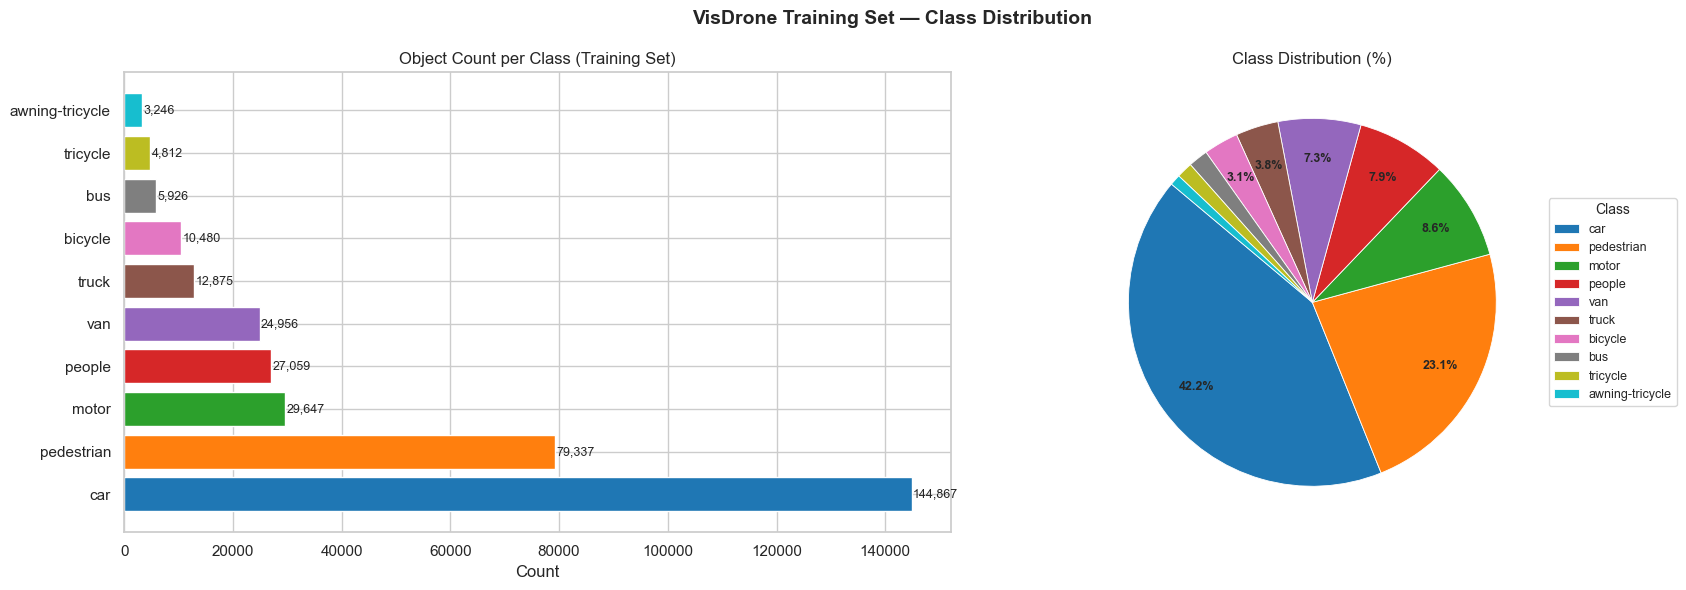


Class counts:
class_name
car                144867
pedestrian          79337
motor               29647
people              27059
van                 24956
truck               12875
bicycle             10480
bus                  5926
tricycle             4812
awning-tricycle      3246


In [12]:
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Count per class
counts = df_valid['class_name'].value_counts()
colors = sns.color_palette('tab10', len(counts))

axes[0].barh(counts.index, counts.values, color=colors)
axes[0].set_xlabel('Count')
axes[0].set_title('Object Count per Class (Training Set)')
for i, v in enumerate(counts.values):
    axes[0].text(v + 200, i, f'{v:,}', va='center', fontsize=9)

# Percentage pie — legend replaces crowded slice labels
wedges, _, autotexts = axes[1].pie(
    counts.values,
    autopct=lambda p: f'{p:.1f}%' if p >= 3 else '',
    startangle=140,
    pctdistance=0.78,
    colors=colors,
    wedgeprops=dict(linewidth=0.6, edgecolor='white'),
)
for at in autotexts:
    at.set_fontsize(9)
    at.set_fontweight('bold')

axes[1].legend(
    wedges, counts.index,
    title='Class',
    loc='center left',
    bbox_to_anchor=(1.0, 0.5),
    fontsize=9,
    title_fontsize=10,
)
axes[1].set_title('Class Distribution (%)')

plt.suptitle('VisDrone Training Set — Class Distribution', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / 'results' / 'class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nClass counts:')
print(counts.to_string())

## 5. Object Size Analysis (Small-Object Challenge)

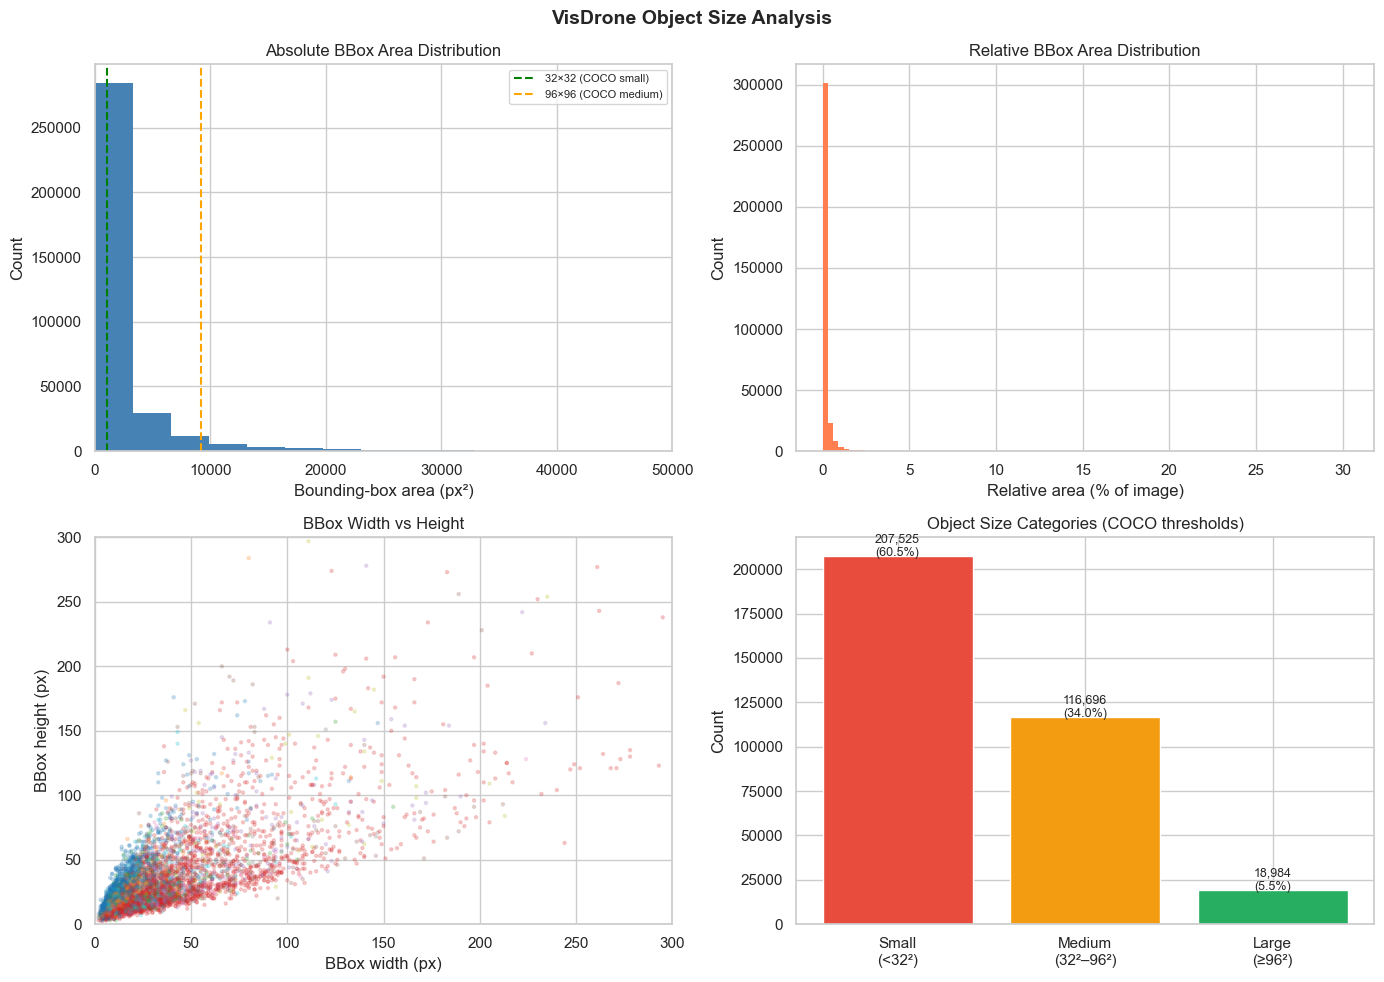

Small  (<32²)  : 207,525  (60.5%)
Medium (32²-96²): 116,696 (34.0%)
Large  (>=96²) : 18,984  (5.5%)


In [6]:
# COCO small/medium/large thresholds in absolute pixels
# But VisDrone uses very small objects — let's also look at relative sizes

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Absolute area distribution
axes[0,0].hist(df_valid['area'], bins=100, color='steelblue', edgecolor='none')
axes[0,0].axvline(32**2, color='green',  linestyle='--', label='32×32 (COCO small)')
axes[0,0].axvline(96**2, color='orange', linestyle='--', label='96×96 (COCO medium)')
axes[0,0].set_xlim(0, 5e4)
axes[0,0].set_xlabel('Bounding-box area (px²)')
axes[0,0].set_ylabel('Count')
axes[0,0].set_title('Absolute BBox Area Distribution')
axes[0,0].legend(fontsize=8)

# Relative area distribution
axes[0,1].hist(df_valid['rel_area'] * 100, bins=100, color='coral', edgecolor='none')
axes[0,1].set_xlabel('Relative area (% of image)')
axes[0,1].set_ylabel('Count')
axes[0,1].set_title('Relative BBox Area Distribution')

# Width vs Height scatter
sample = df_valid.sample(min(5000, len(df_valid)), random_state=42)
axes[1,0].scatter(sample['w'], sample['h'], alpha=0.2, s=5,
                  c=sample['category'], cmap='tab10')
axes[1,0].set_xlabel('BBox width (px)')
axes[1,0].set_ylabel('BBox height (px)')
axes[1,0].set_title('BBox Width vs Height')
axes[1,0].set_xlim(0, 300); axes[1,0].set_ylim(0, 300)

# Size categories
small  = (df_valid['area'] < 32**2).sum()
medium = ((df_valid['area'] >= 32**2) & (df_valid['area'] < 96**2)).sum()
large  = (df_valid['area'] >= 96**2).sum()
axes[1,1].bar(['Small\n(<32²)', 'Medium\n(32²–96²)', 'Large\n(≥96²)'],
              [small, medium, large],
              color=['#e74c3c', '#f39c12', '#27ae60'])
axes[1,1].set_ylabel('Count')
axes[1,1].set_title('Object Size Categories (COCO thresholds)')
for i, v in enumerate([small, medium, large]):
    pct = v / len(df_valid) * 100
    axes[1,1].text(i, v + 100, f'{v:,}\n({pct:.1f}%)', ha='center', fontsize=9)

plt.suptitle('VisDrone Object Size Analysis', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / 'results' / 'object_size_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print(f'Small  (<32²)  : {small:,}  ({small/len(df_valid)*100:.1f}%)')
print(f'Medium (32²-96²): {medium:,} ({medium/len(df_valid)*100:.1f}%)')
print(f'Large  (>=96²) : {large:,}  ({large/len(df_valid)*100:.1f}%)')

## 6. Objects per Image (Density)

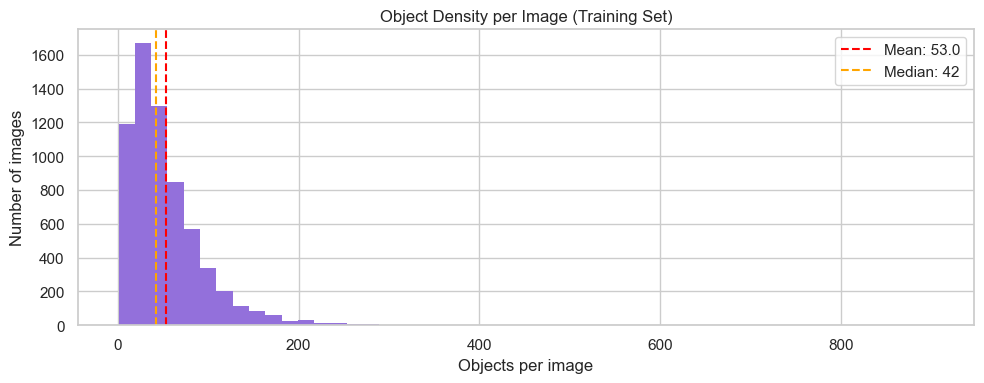

count    6471.000000
mean       53.037398
std        43.841912
min         1.000000
25%        24.000000
50%        42.000000
75%        70.000000
max       902.000000
dtype: float64


In [7]:
density = df_valid.groupby('image').size()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(density, bins=50, color='mediumpurple', edgecolor='none')
ax.axvline(density.mean(), color='red', linestyle='--', label=f'Mean: {density.mean():.1f}')
ax.axvline(density.median(), color='orange', linestyle='--', label=f'Median: {density.median():.0f}')
ax.set_xlabel('Objects per image')
ax.set_ylabel('Number of images')
ax.set_title('Object Density per Image (Training Set)')
ax.legend()
plt.tight_layout()
plt.savefig(ROOT / 'results' / 'object_density.png', dpi=150, bbox_inches='tight')
plt.show()

print(density.describe())

## 7. Sample Image Visualisation

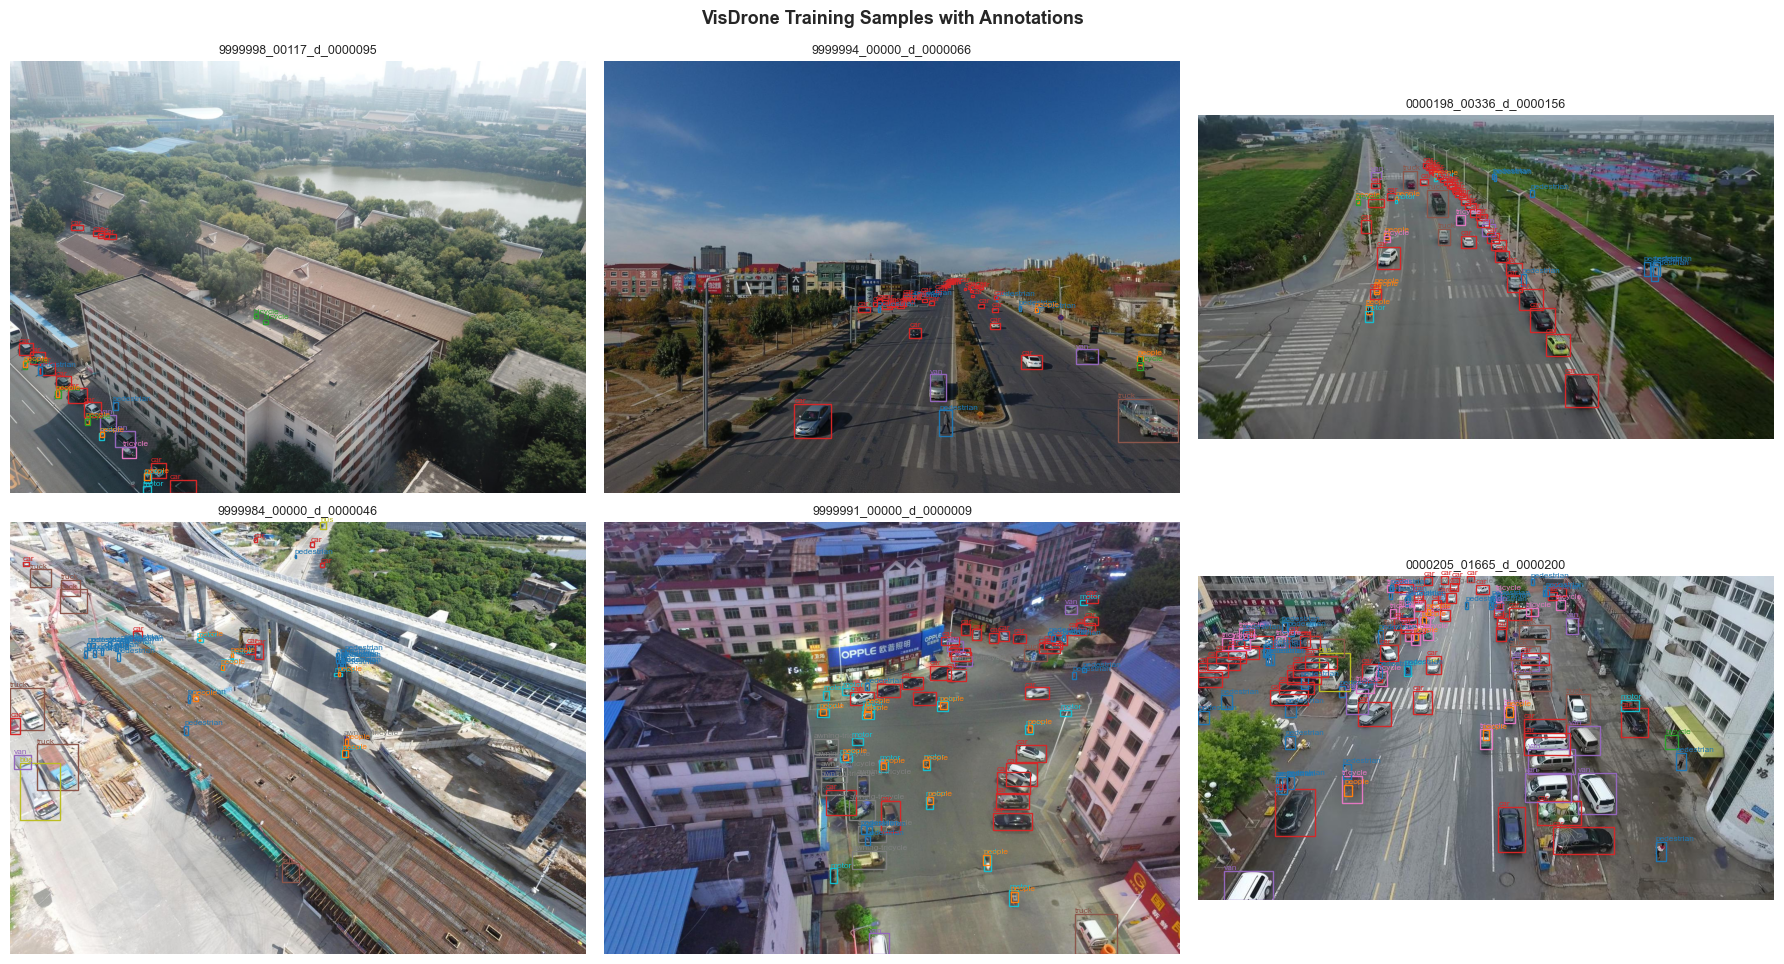

In [8]:
import random

COLORS = plt.cm.tab10.colors  # 10 distinct colors

def visualise_image(img_path, ann_path, ax, title=''):
    img = Image.open(img_path)
    ax.imshow(img)
    with open(ann_path) as f:
        for line in f:
            parts = line.strip().split(',')
            if len(parts) < 6: continue
            x, y, w, h = float(parts[0]), float(parts[1]), float(parts[2]), float(parts[3])
            cat = int(parts[5])
            if cat not in VALID_CLASSES: continue
            color = COLORS[(cat - 1) % len(COLORS)]
            rect = mpatches.Rectangle((x, y), w, h,
                                       linewidth=1, edgecolor=color, facecolor='none')
            ax.add_patch(rect)
            ax.text(x, y - 2, CLASS_NAMES[cat], fontsize=6, color=color)
    ax.axis('off')
    ax.set_title(title, fontsize=9)

img_files = sorted((splits['train'] / 'images').glob('*.jpg'))
samples = random.sample(img_files, min(6, len(img_files)))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
for ax, img_path in zip(axes.flatten(), samples):
    ann_path = splits['train'] / 'annotations' / (img_path.stem + '.txt')
    visualise_image(img_path, ann_path, ax, title=img_path.stem)

plt.suptitle('VisDrone Training Samples with Annotations', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(ROOT / 'results' / 'sample_images.png', dpi=120, bbox_inches='tight')
plt.show()

## 8. Image Resolution Analysis

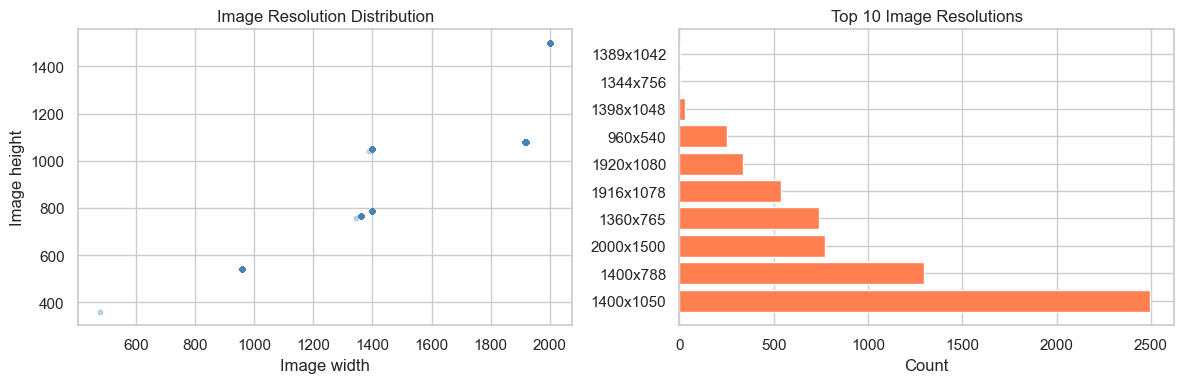

Resolution stats:
             img_w        img_h
count  6471.000000  6471.000000
mean   1519.889507  1002.397002
std     269.521521   235.063535
min     480.000000   360.000000
25%    1400.000000   788.000000
50%    1400.000000  1050.000000
75%    1916.000000  1078.000000
max    2000.000000  1500.000000


In [9]:
resolutions = df[['image', 'img_w', 'img_h']].drop_duplicates()

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(resolutions['img_w'], resolutions['img_h'],
                alpha=0.3, s=10, color='steelblue')
axes[0].set_xlabel('Image width')
axes[0].set_ylabel('Image height')
axes[0].set_title('Image Resolution Distribution')

common = (resolutions['img_w'].astype(str) + 'x' + resolutions['img_h'].astype(str)).value_counts().head(10)
axes[1].barh(common.index, common.values, color='coral')
axes[1].set_xlabel('Count')
axes[1].set_title('Top 10 Image Resolutions')

plt.tight_layout()
plt.savefig(ROOT / 'results' / 'image_resolutions.png', dpi=150, bbox_inches='tight')
plt.show()

print('Resolution stats:')
print(resolutions[['img_w', 'img_h']].describe())

## 9. Run Data Conversion

Convert VisDrone annotations to YOLO format so Ultralytics can consume them directly.

In [10]:
import subprocess
result = subprocess.run(
    ['python', str(ROOT / 'scripts' / 'convert_visdrone_to_yolo.py'),
     '--data_root', str(ROOT / 'Data'),
     '--splits', 'train', 'val', 'test-dev'],
    capture_output=True, text=True, cwd=str(ROOT)
)
print(result.stdout)
if result.returncode != 0:
    print('STDERR:', result.stderr)

Data root: /Users/toriav/Desktop/Erem/CMPE 401/Instructor Projects/Project 1/Object-Detection-Study-using-YOLOv11-or-YOLOv26-/Data

Converting split: train (6471 files) ...
  Done. 6471 files converted, 0 skipped, 343204 objects written.

Converting split: val (548 files) ...
  Done. 548 files converted, 0 skipped, 38759 objects written.

Converting split: test-dev (1610 files) ...
  Done. 1610 files converted, 0 skipped, 75102 objects written.

Conversion complete.
Labels written to: <split>/labels/*.txt



In [11]:
# Verify converted labels exist
for split_name, split_path in splits.items():
    lbl_dir = split_path / 'labels'
    n = len(list(lbl_dir.glob('*.txt'))) if lbl_dir.exists() else 0
    print(f'{split_name:<20}: {n} label files in {lbl_dir.relative_to(ROOT)}')

train               : 6471 label files in data/VisDrone2019-DET-train/labels
val                 : 548 label files in data/VisDrone2019-DET-val/labels
test-dev            : 1610 label files in data/VisDrone2019-DET-test-dev/labels
test-challenge      : 0 label files in data/VisDrone2019-DET-test-challenge/labels


## Summary

Key findings from the EDA:

| Observation | Implication |
|---|---|
| Majority of objects are tiny (< 32×32 px) | Standard 640px input may be insufficient; test 1280px |
| Heavy class imbalance (car >> truck) | May need class-weighted loss or oversampling |
| Dense scenes (many objects per image) | NMS tuning matters; YOLO26 NMS-free head may help |
| Images vary from ~640×480 to 2000×1500 | Consistent resizing needed |

These observations will directly inform the experimental design in subsequent notebooks.